# Time Series Support Vector Regression with Fractal Kernel

> Applications of fractal-type kernels in Gaussian process regression and support vector machine regression
>
> Authors:  Dah-Chin Luor, Chiao-Wen Liu
>
> Paper Date: 18 October 2024

> Submission By: Aditya Kumar


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from rkhs import RKHS

## Data Preprocessing

In [2]:
df = pd.read_csv('./data/Crude Oil WTI Futures Historical Data.csv', parse_dates=['Date'])
df.sort_values(by='Date', ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)
df

,Date,Price,Open,High,Low,Vol.,Change %
0,2021-10-13,79.82,79.83,80.36,78.78,304.96K,-0.13%
1,2021-10-14,80.77,79.94,81.14,79.79,300.57K,1.19%
2,2021-10-15,81.73,80.93,82.00,80.86,284.73K,1.19%
3,2021-10-18,81.69,82.00,83.18,81.21,501.07K,-0.05%
4,2021-10-19,82.44,81.58,82.99,81.08,531.47K,0.92%
...,...,...,...,...,...,...,...
206,2022-07-25,94.42,92.83,94.62,90.79,92.70K,2.15%
207,2022-07-26,92.88,93.95,96.60,92.64,89.07K,-1.63%
208,2022-07-27,95.29,93.51,96.53,92.30,105.40K,2.59%
209,2022-07-28,94.65,96.09,97.82,94.28,96.14K,-0.67%


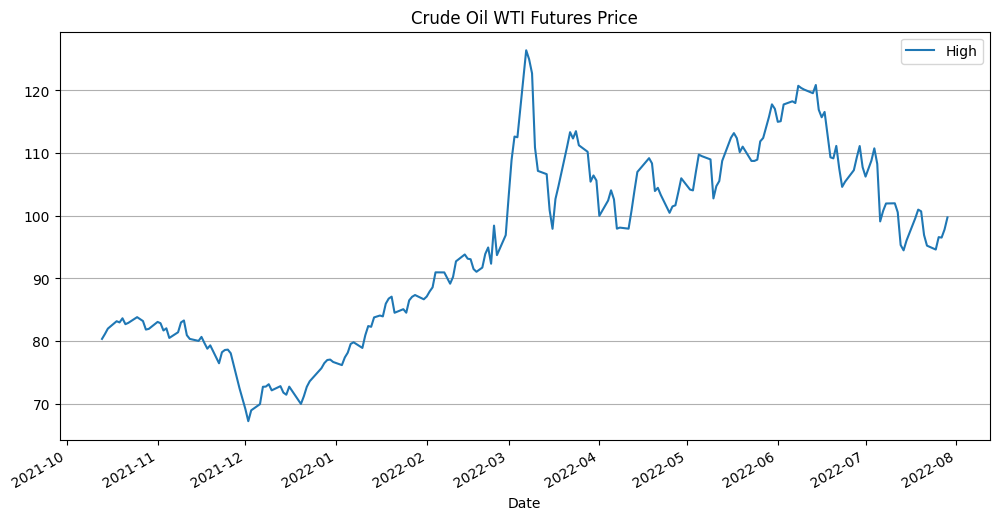

In [3]:
df.plot(x='Date', y='High', figsize=(12, 6), title='Crude Oil WTI Futures Price')
plt.grid(axis='y')
plt.show()

In [4]:
df['x'] = df.index/210
df

,Date,Price,Open,High,Low,Vol.,Change %,x
0,2021-10-13,79.82,79.83,80.36,78.78,304.96K,-0.13%,0.000000
1,2021-10-14,80.77,79.94,81.14,79.79,300.57K,1.19%,0.004762
2,2021-10-15,81.73,80.93,82.00,80.86,284.73K,1.19%,0.009524
3,2021-10-18,81.69,82.00,83.18,81.21,501.07K,-0.05%,0.014286
4,2021-10-19,82.44,81.58,82.99,81.08,531.47K,0.92%,0.019048
...,...,...,...,...,...,...,...,...
206,2022-07-25,94.42,92.83,94.62,90.79,92.70K,2.15%,0.980952
207,2022-07-26,92.88,93.95,96.60,92.64,89.07K,-1.63%,0.985714
208,2022-07-27,95.29,93.51,96.53,92.30,105.40K,2.59%,0.990476
209,2022-07-28,94.65,96.09,97.82,94.28,96.14K,-0.67%,0.995238


<Axes: title={'center': 'Crude Oil WTI Futures Price'}, xlabel='x'>

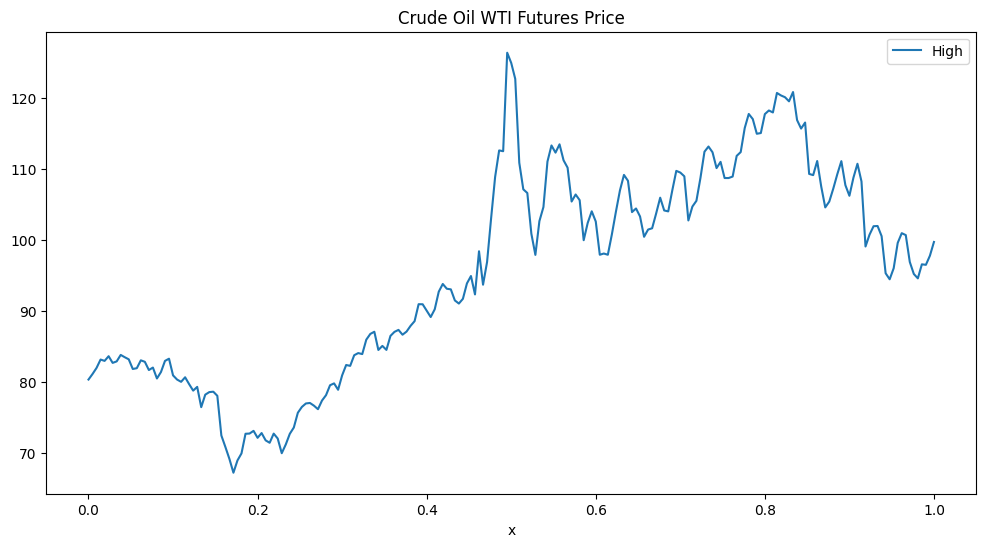

In [5]:
df.plot(x='x', y='High', figsize=(12, 6), title='Crude Oil WTI Futures Price')

In [6]:
#  2021/10/13, 11/11, 12/10, 2022/1/11, 2/8, 3/8, 4/6, 5/6, 6/3, 7/1, 7/29.
date_strings = ['2021-10-13', '2021-11-11', '2021-12-10', '2022-01-11', '2022-02-08','2022-03-08', '2022-04-06', '2022-05-06', '2022-06-03', '2022-07-01', '2022-07-29']
target_dates = pd.to_datetime(date_strings)
df_subsample = df[df['Date'].isin(target_dates)]
df_subsample

,Date,Price,Open,High,Low,Vol.,Change %,x
0,2021-10-13,79.82,79.83,80.36,78.78,304.96K,-0.13%,0.0
21,2021-11-11,80.42,80.10,80.95,78.98,209.70K,0.45%,0.1
42,2021-12-10,71.48,70.52,72.15,70.19,185.50K,0.97%,0.2
63,2022-01-11,80.67,77.87,80.95,77.83,270.56K,3.82%,0.3
84,2022-02-08,87.90,89.98,90.07,87.07,188.54K,-2.08%,0.4
105,2022-03-08,119.65,116.98,124.98,113.66,200.16K,3.32%,0.5
126,2022-04-06,95.41,99.95,102.63,94.93,159.99K,-5.23%,0.6
147,2022-05-06,108.33,107.07,109.53,105.72,119.33K,1.49%,0.7
168,2022-06-03,116.23,114.90,117.77,112.73,74.48K,1.69%,0.8
189,2022-07-01,105.39,103.33,106.26,101.94,99.69K,2.22%,0.9


<Axes: title={'center': 'Crude Oil WTI Futures Price Subsampled'}, xlabel='Date'>

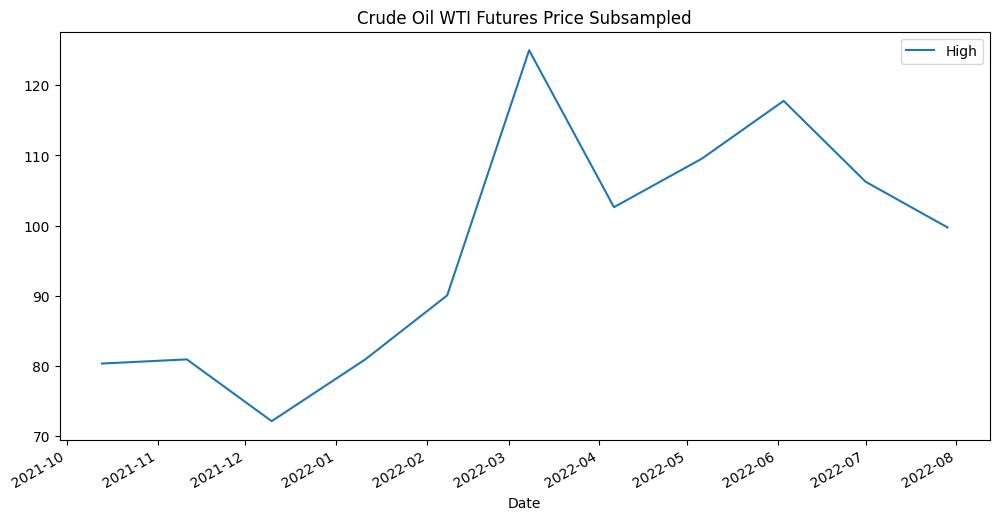

In [7]:
df_subsample.plot(x='Date', y='High', figsize=(12, 6), title='Crude Oil WTI Futures Price Subsampled')

In [8]:
data_series = df_subsample[['x', 'High']].to_numpy()
data_series

array([[0.0000e+00, 8.0360e+01],
       [1.0000e-01, 8.0950e+01],
       [2.0000e-01, 7.2150e+01],
       [3.0000e-01, 8.0950e+01],
       [4.0000e-01, 9.0070e+01],
       [5.0000e-01, 1.2498e+02],
       [6.0000e-01, 1.0263e+02],
       [7.0000e-01, 1.0953e+02],
       [8.0000e-01, 1.1777e+02],
       [9.0000e-01, 1.0626e+02],
       [1.0000e+00, 9.9750e+01]])

In [9]:
fractal_depth = 2
rkhs = RKHS(data_series=data_series, m=11, fractal_depth=fractal_depth)

Vertical scaling factors s_values were not provided, so they were initialised randomly.
Building the Basis functions for the RKHS:
	Built F_[u_1].
	Built F_[u_2].
	Built F_[u_3].
	Built F_[u_4].
	Built F_[u_5].
	Built F_[u_6].
	Built F_[u_7].
	Built F_[u_8].
	Built F_[u_9].
	Built F_[u_10].
	Built F_[u_11].
Established the refined x grid with 1001 points.
Built matrix A = [<F_[u_i], F_[u_j]>].
Built matrix B = inverse(A).


In [10]:
print("Matrix A (inner products between fractal basis functions):")
print(np.round(rkhs.A, decimals=2))
print("\nMatrix B (inverse of A):")
print(np.round(rkhs.B, decimals=2))

Matrix A (inner products between fractal basis functions):
[[ 1.    0.    0.16 -0.    0.15 -0.    0.06  0.   -0.05 -0.    0.15]
 [ 0.    0.51 -0.    0.03  0.04 -0.01  0.06  0.    0.07 -0.03 -0.03]
 [ 0.16 -0.    1.03 -0.11  0.14 -0.17 -0.03 -0.15 -0.27  0.03  0.18]
 [-0.    0.03 -0.11  1.06  0.06  0.    0.09  0.13 -0.24  0.04 -0.  ]
 [ 0.15  0.04  0.14  0.06  1.08 -0.09 -0.01 -0.04  0.06  0.14  0.17]
 [-0.   -0.01 -0.17  0.   -0.09  1.1   0.1   0.03 -0.08  0.03 -0.04]
 [ 0.06  0.06 -0.03  0.09 -0.01  0.1   0.95  0.01 -0.25  0.09  0.02]
 [ 0.    0.   -0.15  0.13 -0.04  0.03  0.01  0.79 -0.07  0.1   0.14]
 [-0.05  0.07 -0.27 -0.24  0.06 -0.08 -0.25 -0.07  1.13 -0.02 -0.06]
 [-0.   -0.03  0.03  0.04  0.14  0.03  0.09  0.1  -0.02  0.88  0.01]
 [ 0.15 -0.03  0.18 -0.    0.17 -0.04  0.02  0.14 -0.06  0.01  1.1 ]]

Matrix B (inverse of A):
[[ 1.06  0.01 -0.14 -0.   -0.13 -0.03 -0.07 -0.02 -0.    0.04 -0.09]
 [ 0.01  2.04 -0.08 -0.08 -0.09  0.   -0.18 -0.06 -0.19  0.11  0.09]
 [-0.14 -0.08  1.

In [11]:
np.linalg.eigvals(rkhs.A)

array([1.66082579, 1.49667447, 0.42737145, 0.55203237, 0.62499452,
       1.20079553, 1.10594822, 0.7922898 , 0.85235997, 0.91272238,
       1.01521956])

In [12]:
K = rkhs.kernel_array(data_series[:, 0][:, None], data_series[:, 0][None, :])
K[:3,:3]

array([[12.44367008,  0.51448384,  0.89951005],
       [ 0.51448384,  6.76738538,  0.68684319],
       [ 0.89951005,  0.68684319,  8.37846012]])

In [13]:
total_data_series = df[['x', 'High']].to_numpy()
total_data_series.shape

(211, 2)

## Modelling

In [14]:
X = total_data_series[:, 0][:, None]
y = total_data_series[:, 1]

In [15]:
def kernel_builder(X, Y):
    return rkhs.kernel_array(X, Y.T)

### Fractal Kernel Based SVR without hyperparameter tuning

In [17]:
svr_model = SVR(kernel=kernel_builder, C = 10)

svr_model.fit(data_series[:,0][:, None], data_series[:,1])

y_pred = svr_model.predict(X)

y_pred[:5], y[:5]
mean_squared_error(y, y_pred)

179.15915935937105

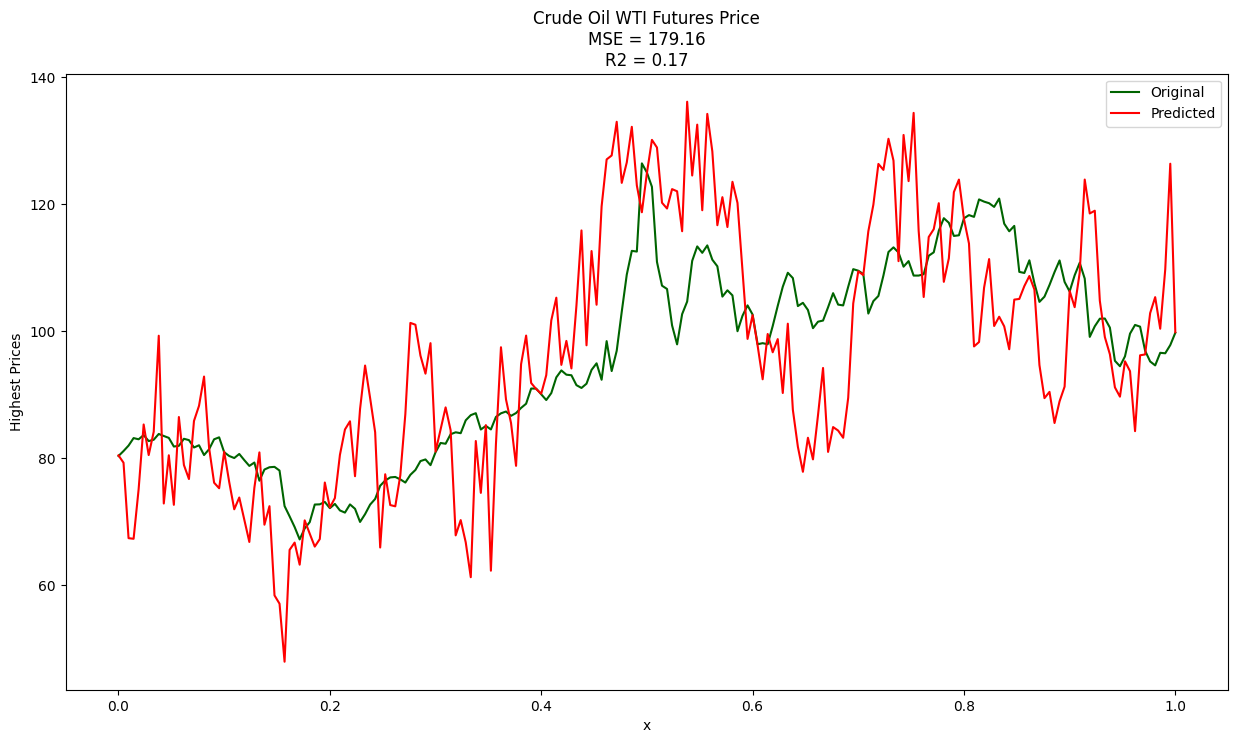

In [18]:
plt.figure(figsize=(15, 8))
plt.plot(X[:,0], y, label='Original', color='darkgreen')
plt.plot(X[:,0], y_pred, label='Predicted', color='red')
plt.xlabel('x')
plt.ylabel('Highest Prices')
plt.title('Crude Oil WTI Futures Price\n'
          f'MSE = {mean_squared_error(y, y_pred):.2f}\n'
          f'R2 = {r2_score(y, y_pred):.2f}')
plt.legend()
plt.show()

## Hyperparameter Tuning

In [19]:
import optuna
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

In [20]:
def fractal_kernel(rkhs: RKHS):
    def k(X, Y):
        return rkhs.kernel_array(X, Y.T)
    
    return k

In [21]:
params_list = []
loss_list = []

In [22]:
# Optuna objective
def objective(trial):
    # 1) Suggest each element of the matrix B
    B = np.zeros((11, 10), dtype=float)
    for i in range(11):
        for j in range(10):
            B[i, j] = trial.suggest_float(f"B_{i}_{j}", -0.99, 0.99)

    rkhs = RKHS(data_series=data_series, m=11, fractal_depth=2, s_values=B)
    
    kernel = fractal_kernel(rkhs)

    svr = SVR(kernel=kernel, C = 10)

    svr.fit(data_series[:,0][:, None], data_series[:,1])
    y_pred = svr.predict(X)

    mse = mean_squared_error(y, y_pred)

    params_list.append(B.flatten())
    loss_list.append(mse)
    
    return mse

In [23]:
warm_up_sampler = optuna.samplers.QMCSampler(seed=42)

sampler = optuna.samplers.CmaEsSampler(n_startup_trials=500, seed=42,independent_sampler=warm_up_sampler)
study = optuna.create_study(direction="minimize", sampler=sampler)

optuna.logging.set_verbosity(optuna.logging.WARNING)

study.optimize(objective, n_trials=700, show_progress_bar=True)

print("Best vertical scaling factors:")
for k, v in study.best_params.items():
    print(f"  {k} = {v:.4f}")
print("Best MSE:", study.best_value)


C:\Users\adity\AppData\Local\Temp\ipykernel_28656\3639620029.py:1: ExperimentalWarning: QMCSampler is experimental (supported from v3.0.0). The interface can change in the future.
  warm_up_sampler = optuna.samplers.QMCSampler(seed=42)
[I 2025-05-20 23:31:34,863] A new study created in memory with name: no-name-27e8e570-e482-4d00-af08-6cb45bf9657b


  0%|          | 0/700 [00:00<?, ?it/s]

Building the Basis functions for the RKHS:
	Built F_[u_1].
	Built F_[u_2].
	Built F_[u_3].
	Built F_[u_4].
	Built F_[u_5].
	Built F_[u_6].
	Built F_[u_7].
	Built F_[u_8].
	Built F_[u_9].
	Built F_[u_10].
	Built F_[u_11].
Established the refined x grid with 1001 points.
Built matrix A = [<F_[u_i], F_[u_j]>].
Built matrix B = inverse(A).
Building the Basis functions for the RKHS:
	Built F_[u_1].
	Built F_[u_2].
	Built F_[u_3].
	Built F_[u_4].
	Built F_[u_5].
	Built F_[u_6].
	Built F_[u_7].
	Built F_[u_8].
	Built F_[u_9].
	Built F_[u_10].
	Built F_[u_11].
Established the refined x grid with 1001 points.
Built matrix A = [<F_[u_i], F_[u_j]>].
Built matrix B = inverse(A).
Building the Basis functions for the RKHS:
	Built F_[u_1].
	Built F_[u_2].
	Built F_[u_3].
	Built F_[u_4].
	Built F_[u_5].
	Built F_[u_6].
	Built F_[u_7].
	Built F_[u_8].
	Built F_[u_9].
	Built F_[u_10].
	Built F_[u_11].
Established the refined x grid with 1001 points.
Built matrix A = [<F_[u_i], F_[u_j]>].
Built matrix B 

In [24]:
s_values = np.zeros((11, 10), dtype=float)
for i in range(11):
    for j in range(10):
        s_values[i, j] = study.best_params[f"B_{i}_{j}"]

print("Best vertical scaling factors:")
print(np.round(s_values, decimals=2))

rkhs = RKHS(data_series=data_series, m=11, fractal_depth=2, s_values=s_values)
kernel = fractal_kernel(rkhs)
svr_model = SVR(kernel=kernel, C = 10)
svr_model.fit(data_series[:,0][:, None], data_series[:,1])
y_pred = svr_model.predict(X)

Best vertical scaling factors:
[[ 0.81 -0.81 -0.07 -0.07  0.51 -0.43  0.01  0.43 -0.78 -0.31]
 [ 0.01 -0.15 -0.18  0.13 -0.74  0.24 -0.19 -0.41  0.17  0.03]
 [ 0.13  0.09 -0.11 -0.32 -0.39 -0.25  0.37  0.42  0.19 -0.33]
 [ 0.32  0.26  0.03  0.11 -0.02  0.64 -0.23  0.41 -0.47 -0.15]
 [ 0.44 -0.29 -0.06  0.35  0.51  0.34  0.21  0.07  0.16  0.36]
 [ 0.69 -0.33  0.3   0.39  0.28  0.39  0.46  0.36 -0.5   0.08]
 [-0.07 -0.29 -0.37 -0.31 -0.05 -0.42 -0.17 -0.21 -0.16 -0.37]
 [-0.03  0.65 -0.05 -0.21  0.01  0.14  0.11 -0.05  0.13  0.84]
 [ 0.17  0.22 -0.39 -0.46  0.77  0.44  0.46  0.53 -0.45 -0.99]
 [ 0.01  0.59 -0.18 -0.14 -0.16 -0.3  -0.12 -0.05 -0.25  0.66]
 [ 0.64 -0.35 -0.12  0.1  -0.18  0.01 -0.13 -0.25 -0.38 -0.73]]
Building the Basis functions for the RKHS:
	Built F_[u_1].
	Built F_[u_2].
	Built F_[u_3].
	Built F_[u_4].
	Built F_[u_5].
	Built F_[u_6].
	Built F_[u_7].
	Built F_[u_8].
	Built F_[u_9].
	Built F_[u_10].
	Built F_[u_11].
Established the refined x grid with 1001 points.
Built

- Grammian Matrix of the RKHS, its eigen values and its inverse. 

In [25]:
# Print out the matrix A (inner products) and its inverse B.
print("Matrix A (inner products between fractal basis functions):")
print(np.round(rkhs.A, decimals=2))
print()
print("Eigenvalues of A:")
print(np.round(np.linalg.eigvals(rkhs.A), decimals=2))
print()
print("\nMatrix B (inverse of A):")
print(np.round(rkhs.B, decimals=2))

Matrix A (inner products between fractal basis functions):
[[ 1.    0.    0.02  0.   -0.25  0.    0.18  0.   -0.03  0.    0.12]
 [ 0.    0.5   0.03 -0.    0.04 -0.   -0.01  0.   -0.07 -0.   -0.14]
 [ 0.02  0.03  0.51 -0.15  0.11 -0.02  0.01  0.01  0.29 -0.02  0.04]
 [ 0.   -0.   -0.15  0.6  -0.01  0.03 -0.04  0.   -0.29 -0.05 -0.01]
 [-0.25  0.04  0.11 -0.01  0.41 -0.1  -0.11 -0.03 -0.04 -0.02 -0.04]
 [ 0.   -0.   -0.02  0.03 -0.1   0.69 -0.05 -0.07 -0.08 -0.09 -0.08]
 [ 0.18 -0.01  0.01 -0.04 -0.11 -0.05  0.58  0.03  0.1  -0.03 -0.03]
 [ 0.    0.    0.01  0.   -0.03 -0.07  0.03  0.58  0.15  0.   -0.03]
 [-0.03 -0.07  0.29 -0.29 -0.04 -0.08  0.1   0.15  0.99  0.01  0.02]
 [ 0.   -0.   -0.02 -0.05 -0.02 -0.09 -0.03  0.    0.01  0.57  0.05]
 [ 0.12 -0.14  0.04 -0.01 -0.04 -0.08 -0.03 -0.03  0.02  0.05  0.67]]

Eigenvalues of A:
[1.34 1.19 0.81 0.2  0.71 0.62 0.56 0.52 0.35 0.39 0.4 ]


Matrix B (inverse of A):
[[ 1.3  -0.08 -0.32  0.    0.86  0.09 -0.28  0.02  0.2   0.03 -0.19]
 [-0.08  

- Distribution of $k(x,x)$ over $x \in [0, 1]$

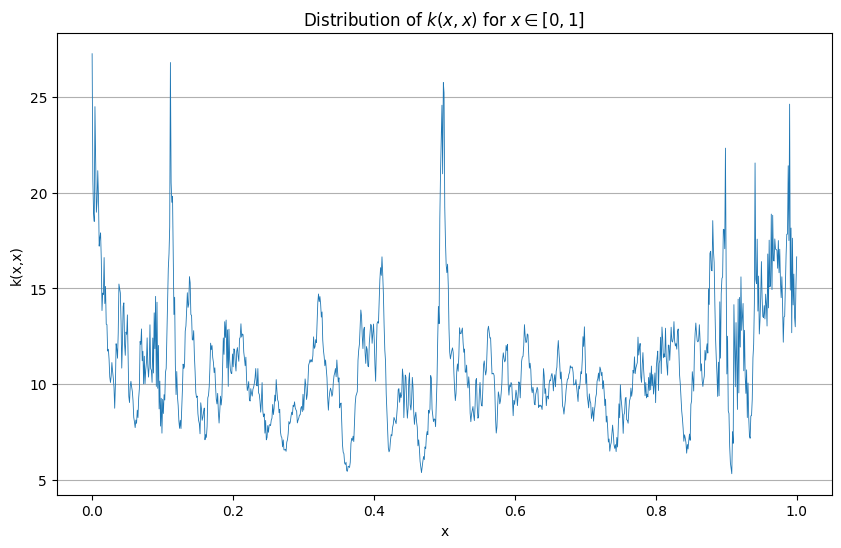

In [26]:
x_plot = np.linspace(0, 1, 1000)
plt.figure(figsize=(10, 6))

kf = np.array([rkhs.kernel_function(x,x) for x in x_plot])
# rkhs_obj.kernel_array(x_plot, x_plot)
plt.plot(x_plot, kf, linewidth=0.6)
plt.title(r"Distribution of $k(x, x)$ for $x \in [0, 1]$")
plt.xlabel("x")
# plt.legend()
plt.ylabel("k(x,x)")
plt.grid(axis='y')
plt.show()

- Trends in reproducing kernel  $k_{x'}(x)$ for $x' \in \{0, 1\}$

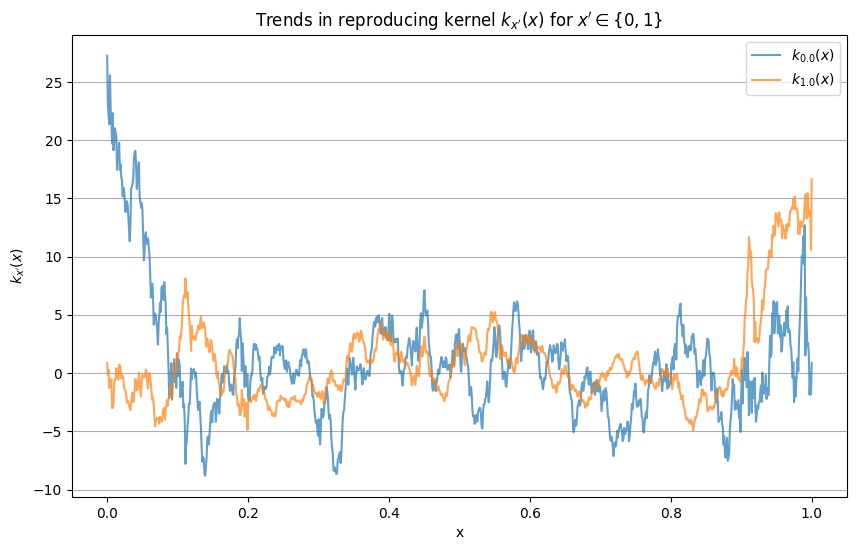

In [27]:
def reproducing_kernel(x_):
    return lambda x: rkhs.kernel_array(x, (np.zeros_like(x)+x_))

x_plot = np.linspace(0, 1, 1000)
plt.figure(figsize=(10, 6))
for i in range(2):
    x_ = i/1.0
    y_plot = reproducing_kernel(x_)(x_plot)
    x_str = f"{x_}"
    label_str = r"$k_{"
    label_str += x_str
    label_str += r"}(x)$"
    plt.plot(x_plot, y_plot, label=label_str, alpha=0.7)
plt.title(r"Trends in reproducing kernel $k_{x'}(x)$ for $x' \in \{0, 1\}$")
plt.xlabel("x")
plt.ylabel(r"$k_{x'}(x)$")
plt.legend()
plt.grid(axis='y')
plt.show()

- Plots of the Fractal Basis Functions and their corresponding spectrums

In [28]:
import fif

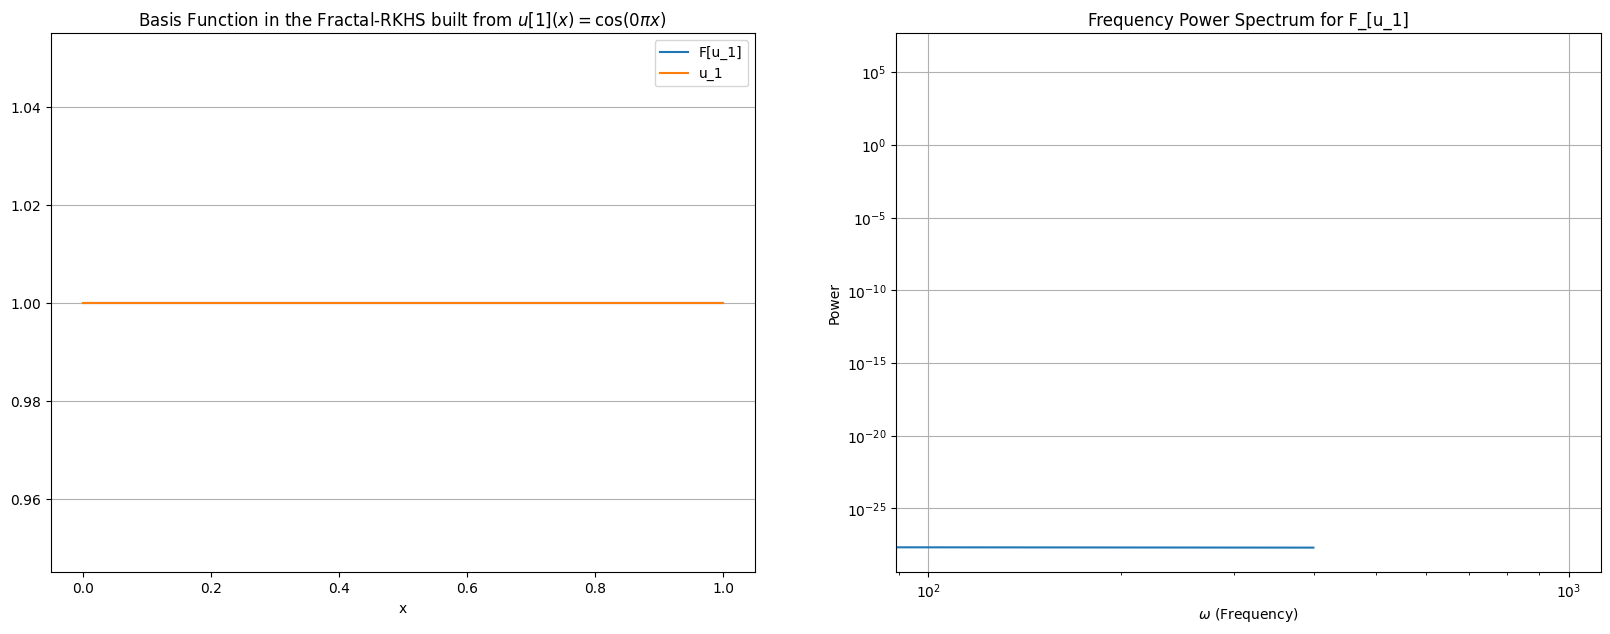

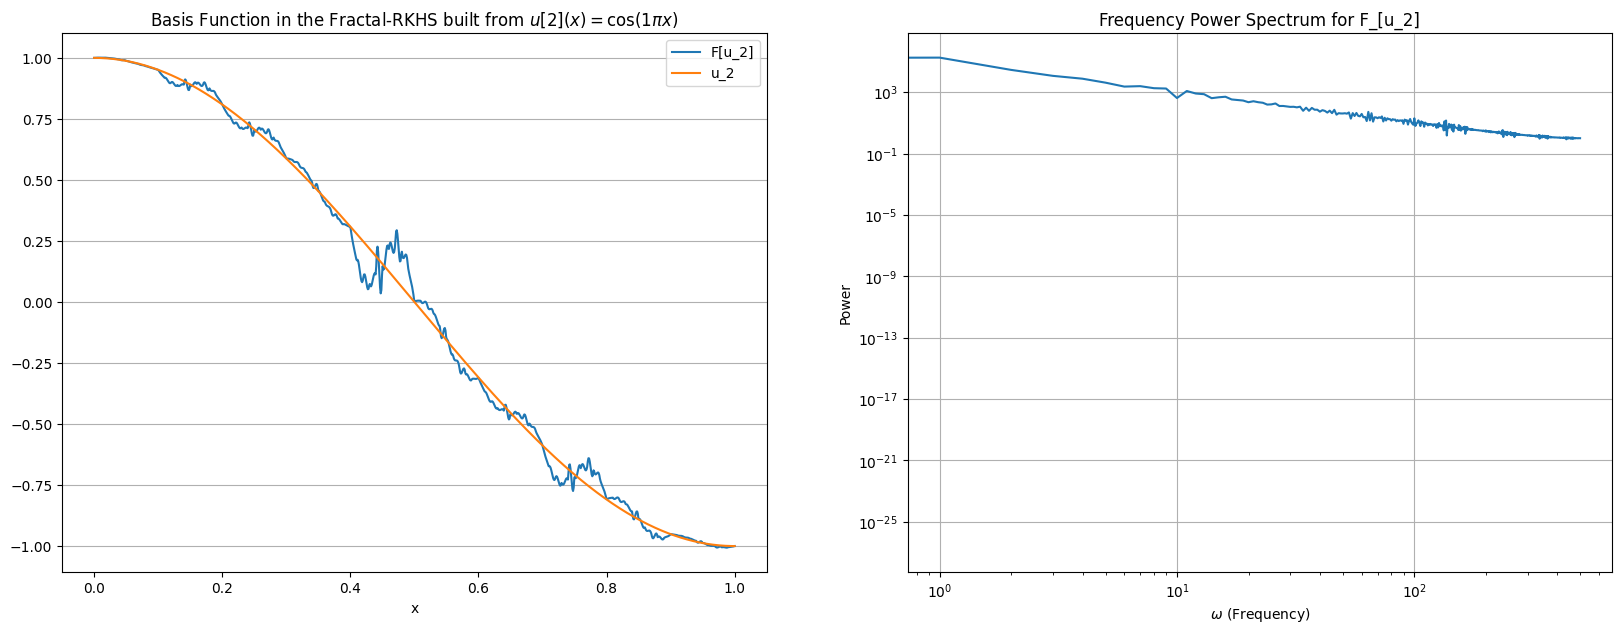

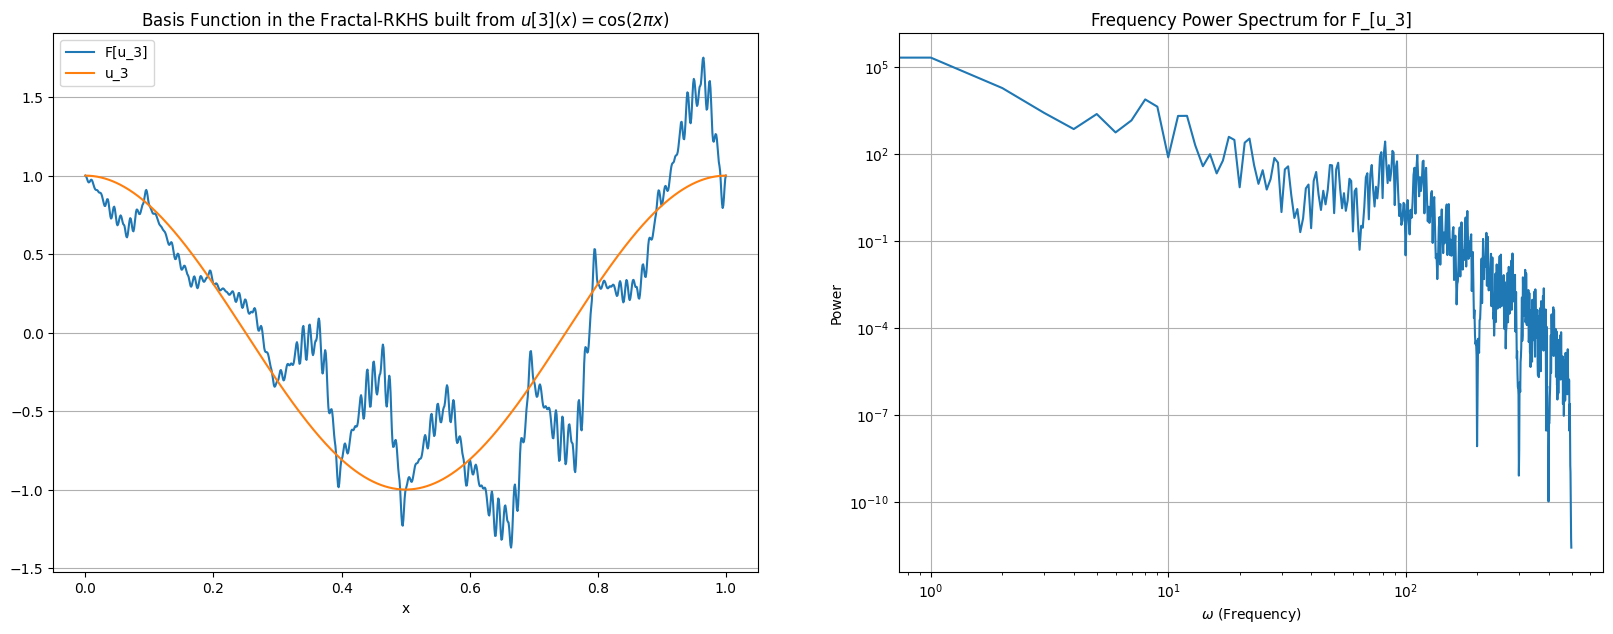

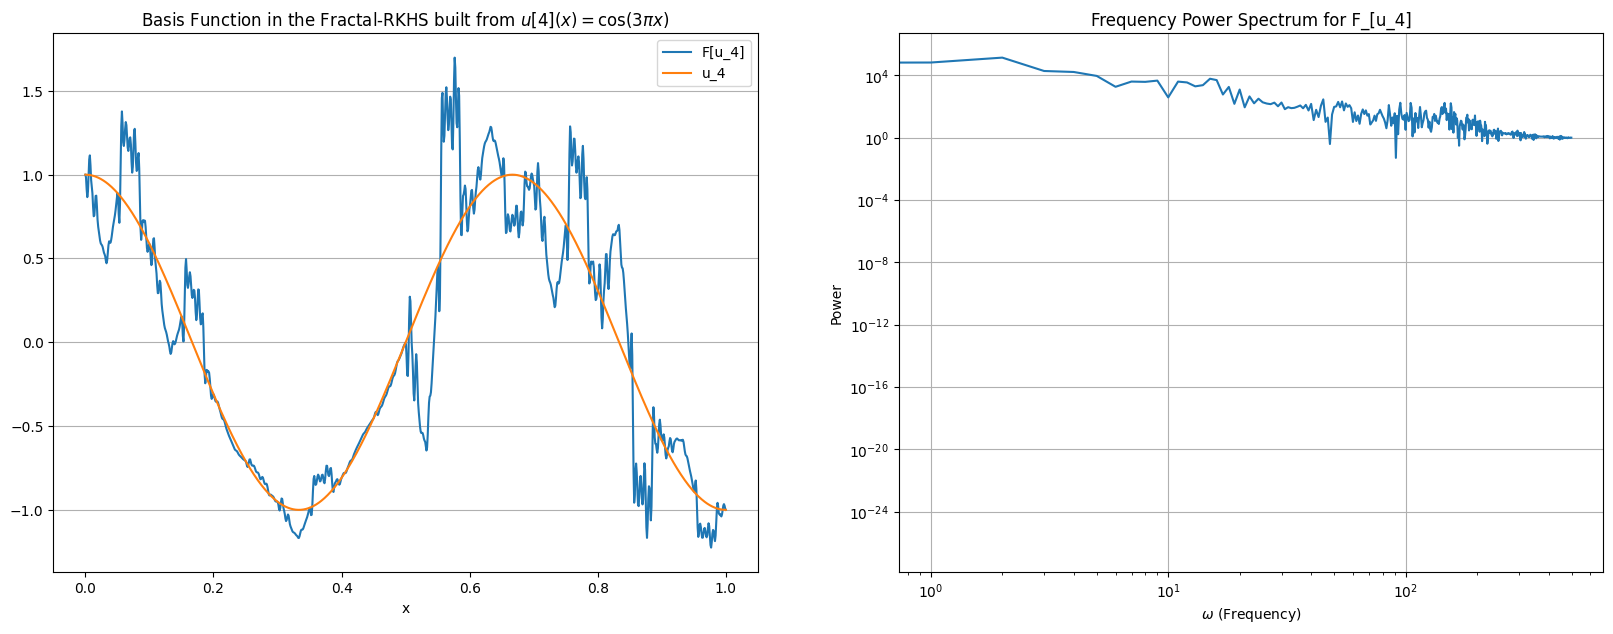

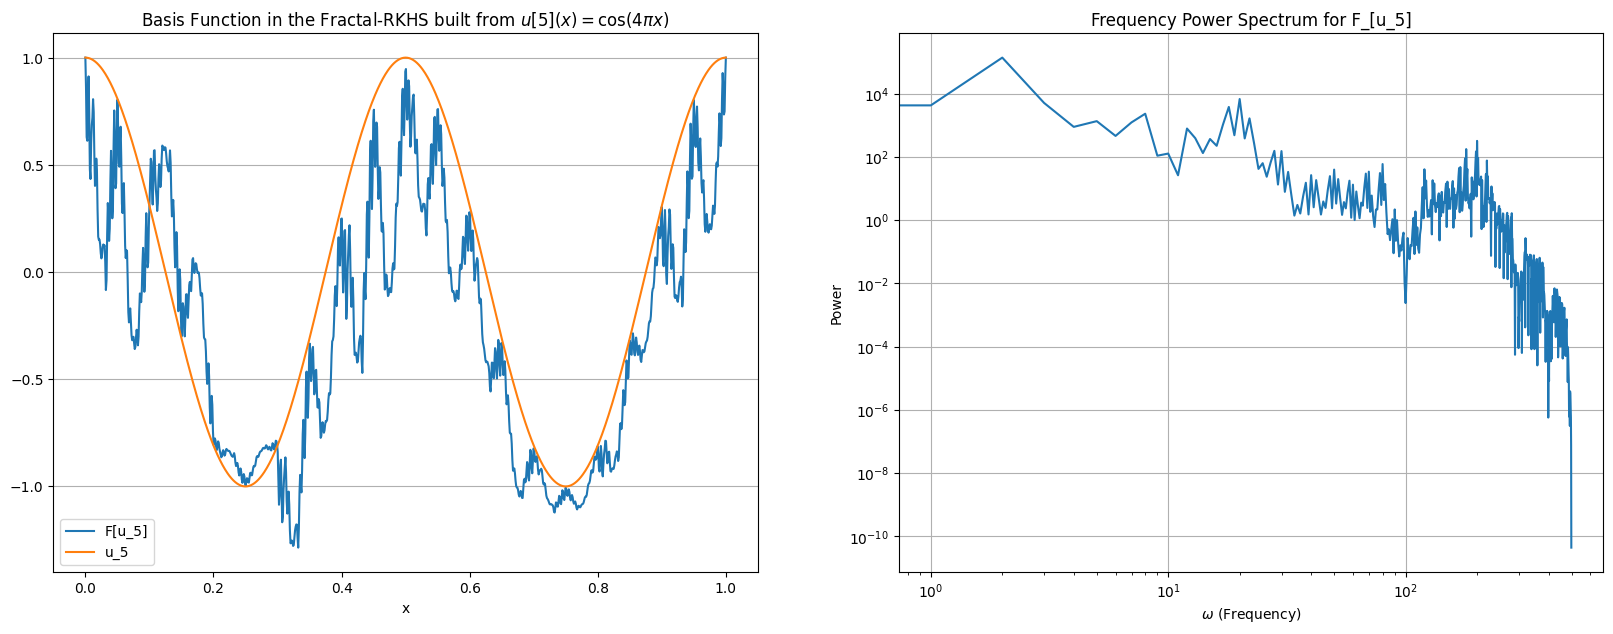

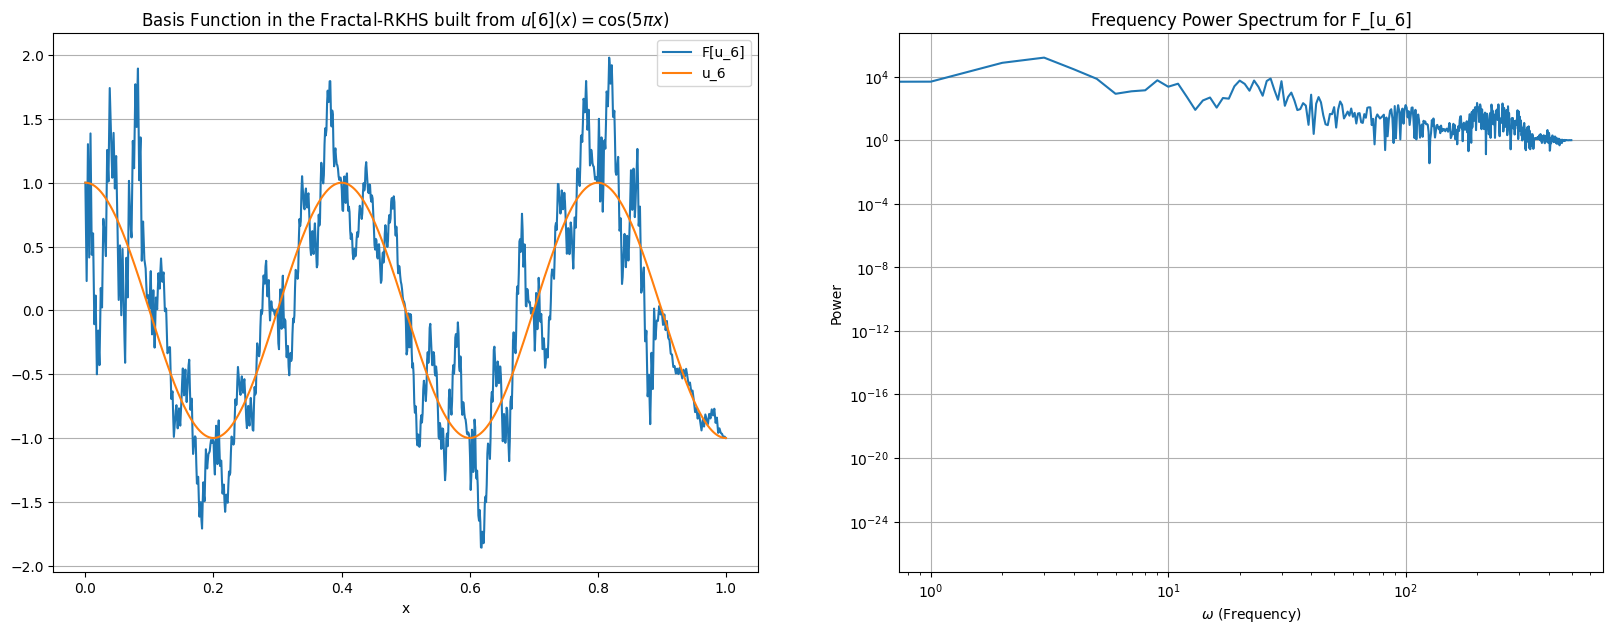

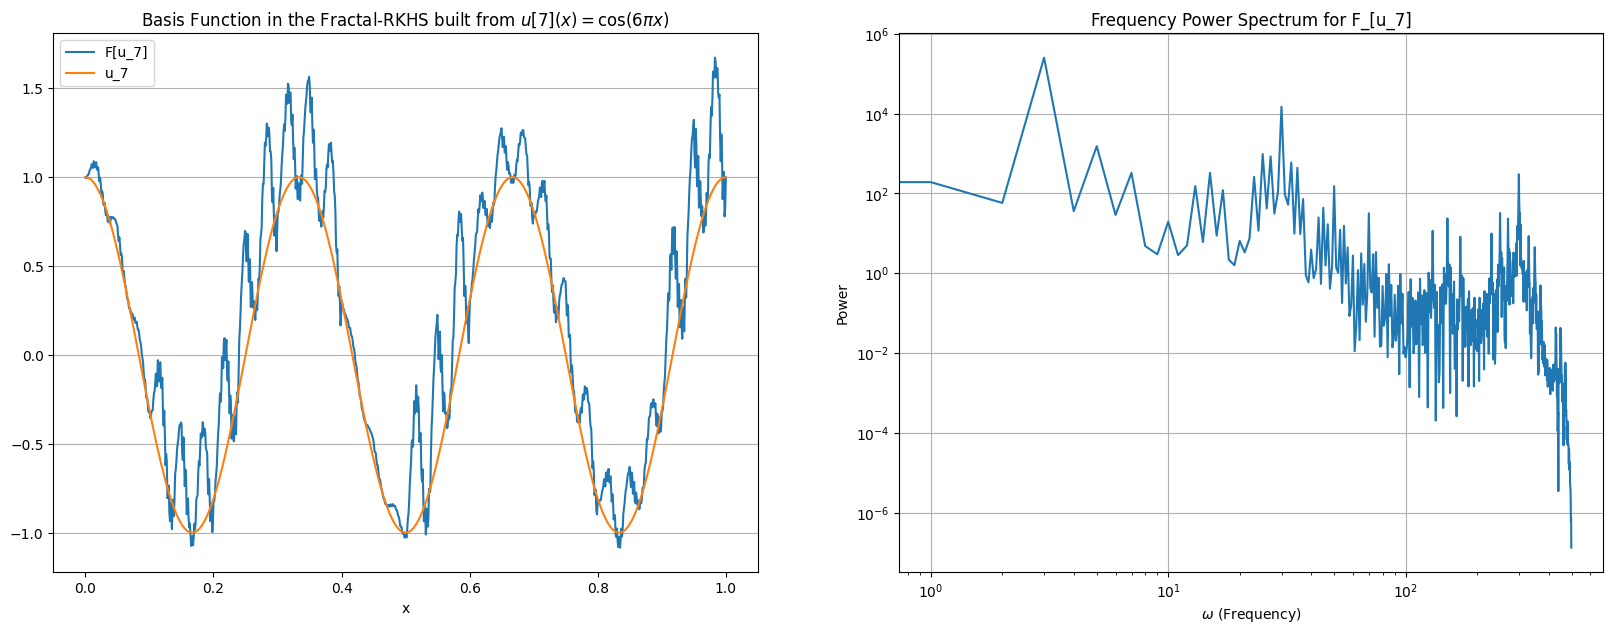

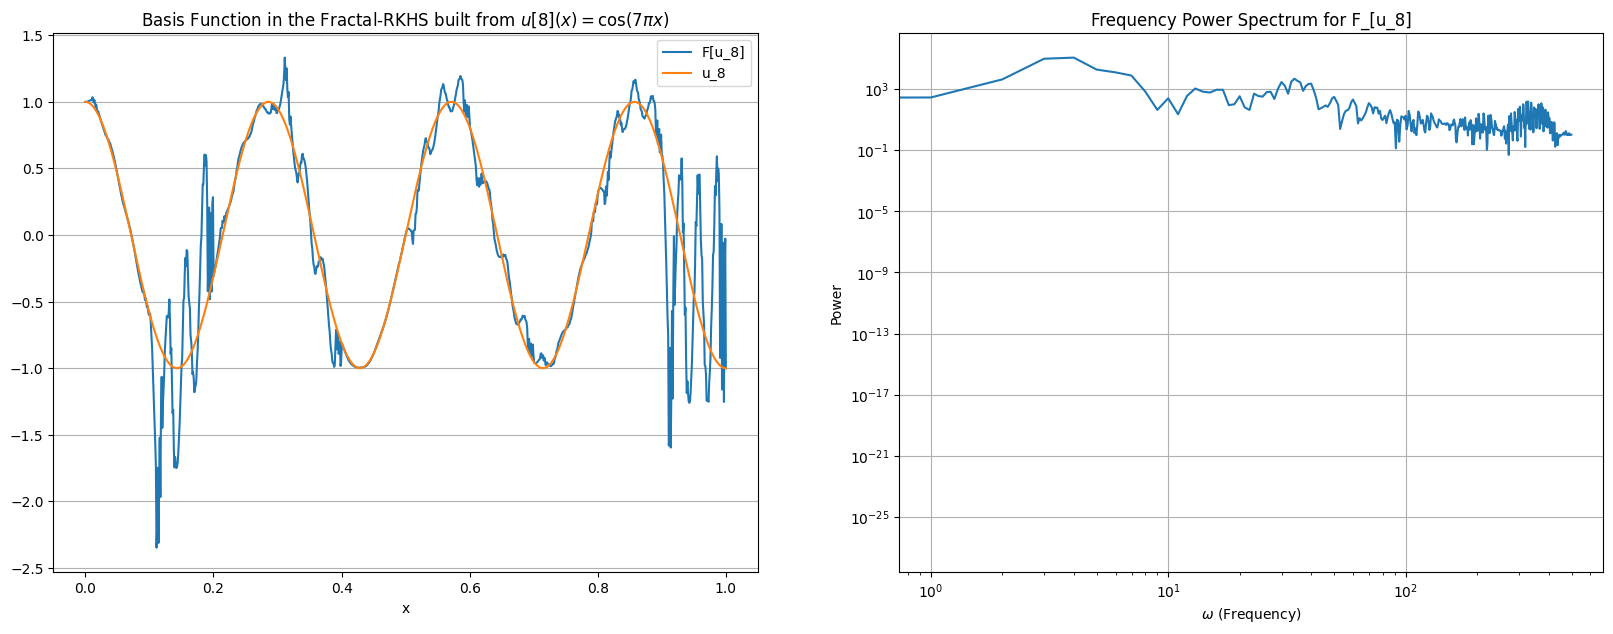

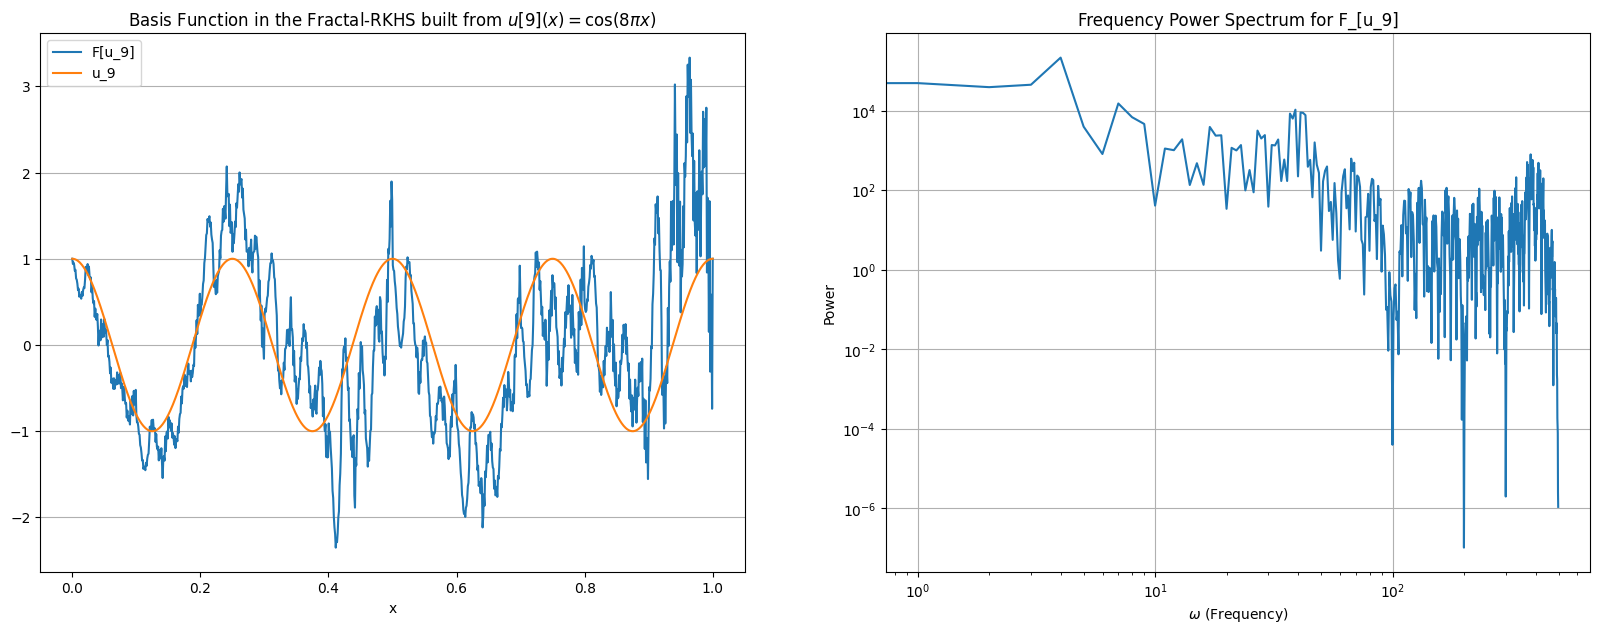

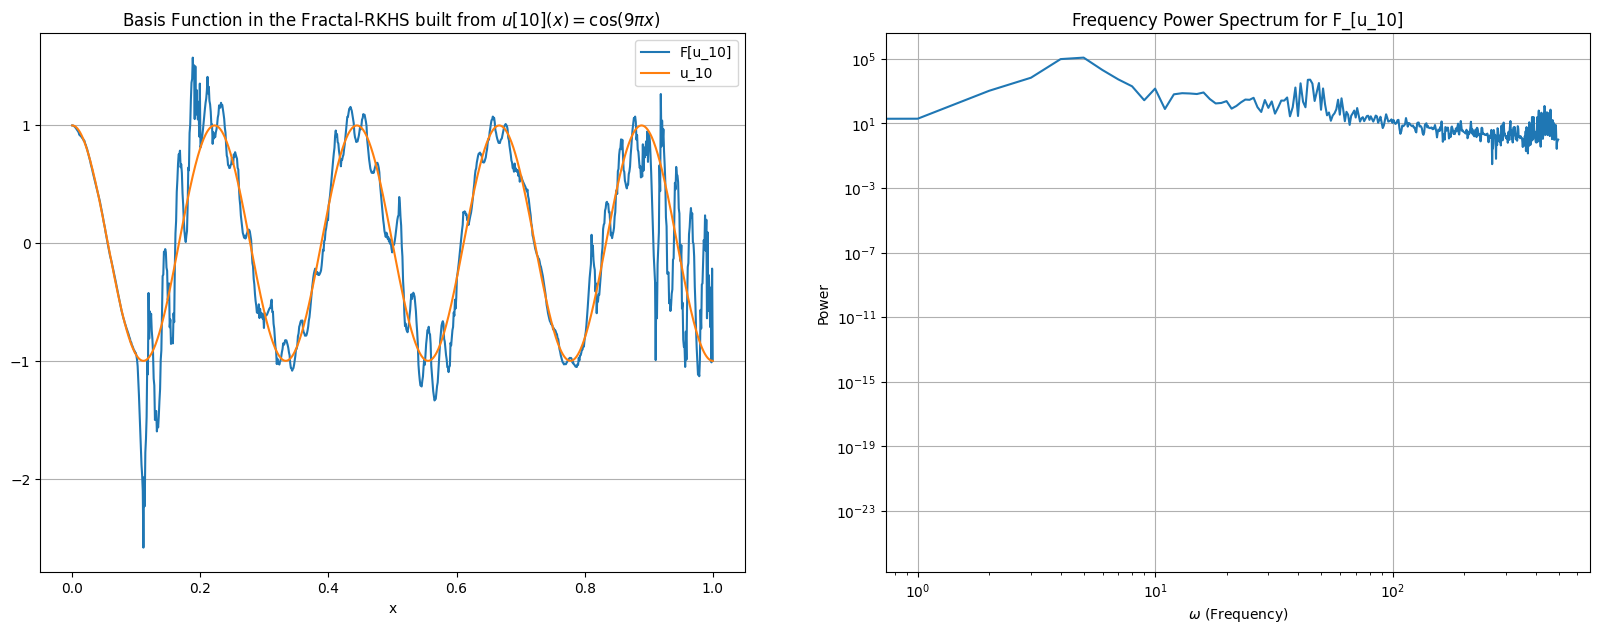

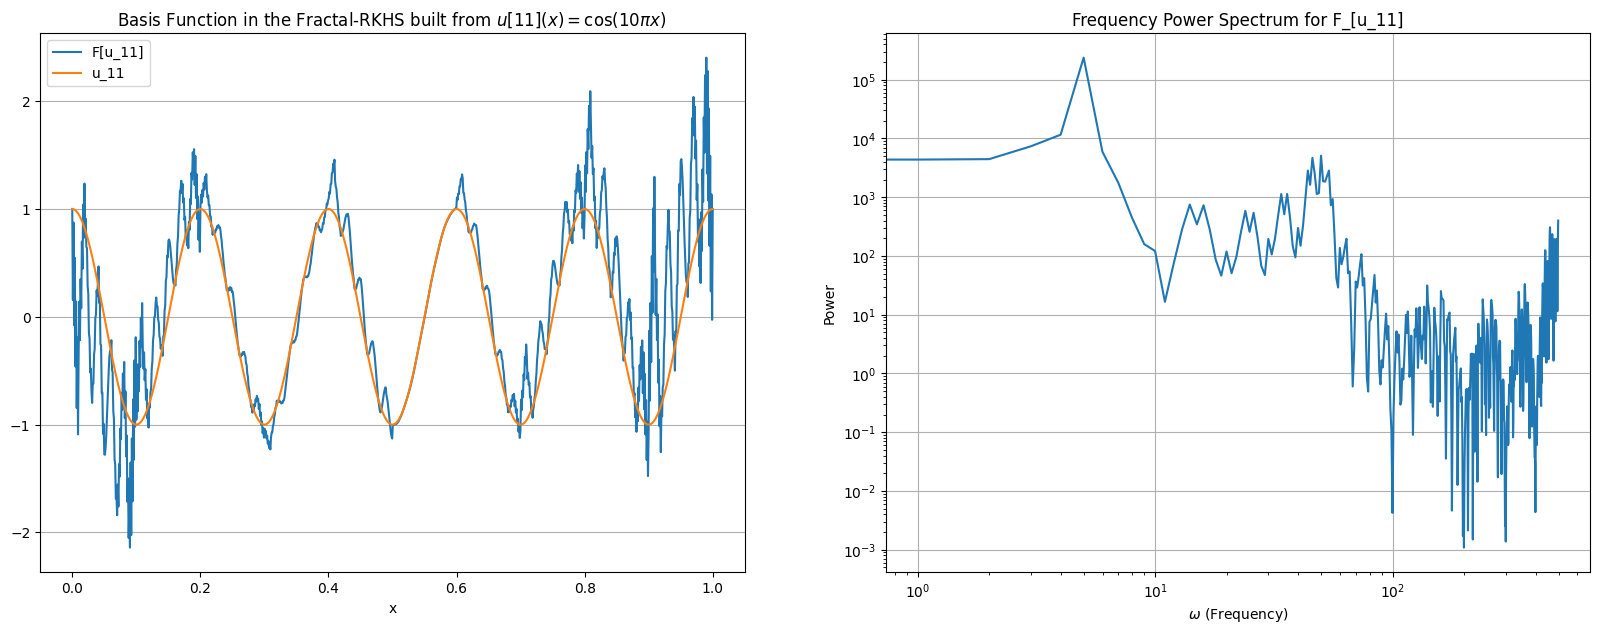

In [30]:
x_plot = np.linspace(0, 1, 1000)

for i in range(1, 11+1):
    fig, axs = plt.subplots(1, 2, figsize=(10*2, 7))
    Fi = rkhs.fractal_basis[f"{i}"]
    ui = fif.u(i-1)
    y_vals = np.array([Fi(xi) for xi in x_plot])

    # Plot the functions
    axs[0].plot(x_plot, y_vals, label=f"F[u_{i}]")
    axs[0].plot(x_plot, ui(x_plot), label=f"u_{i}")
    axs[0].set_title(rf"Basis Function in the Fractal-RKHS built from $u[{i}](x) = \cos({i-1}\pi x)$ ")
    axs[0].set_xlabel("x")
    axs[0].legend()
    axs[0].grid(axis='y')

    # Plot their spectrums
    fft_values = np.fft.fft(y_vals)
    freqs = np.fft.fftfreq(len(x_plot), x_plot[1]-x_plot[0])
    power_spectrum = np.abs(fft_values)**2

    positive_freqs = freqs[:len(freqs)//2]
    positive_power = power_spectrum[:len(power_spectrum)//2]
    mask = (positive_power > 0)

    axs[1].loglog(positive_freqs[mask], positive_power[mask])
    axs[1].set_title(f"Frequency Power Spectrum for F_[u_{i}]")
    axs[1].set_xlabel(r"$\omega$ (Frequency)")
    axs[1].set_ylabel("Power")
    axs[1].grid(axis='both')
    plt.show()

- Plot of the Fitted Regressor and the original time series.

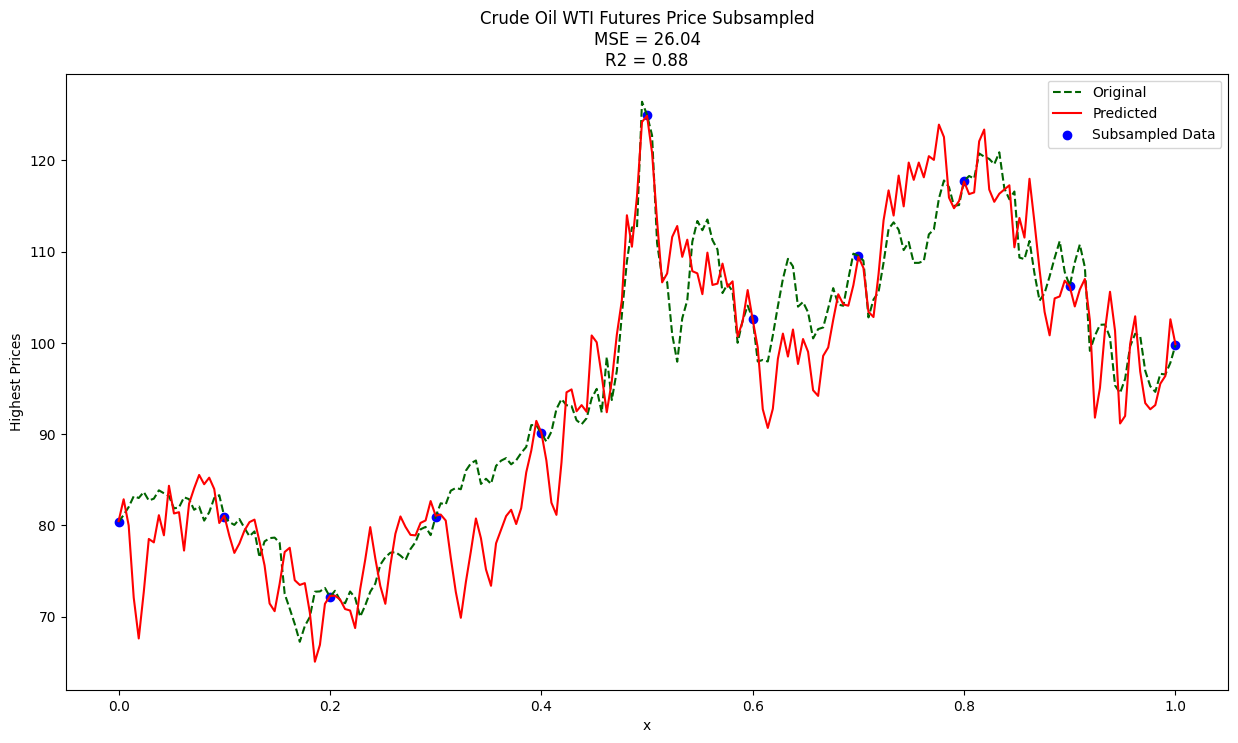

In [31]:
plt.figure(figsize=(15, 8))
plt.plot(X[:,0], y, label='Original', color='darkgreen', linestyle='--')
plt.plot(X[:,0], y_pred, label='Predicted', color='red')
plt.scatter(data_series[:,0], data_series[:, 1], color='blue', label='Subsampled Data', marker='o')

plt.xlabel('x')
plt.ylabel('Highest Prices')
plt.title('Crude Oil WTI Futures Price Subsampled\n'
          f'MSE = {mean_squared_error(y, y_pred):.2f}\n'
          f'R2 = {r2_score(y, y_pred):.2f}')
plt.legend()
plt.show()

## With RBF

In [42]:
rbf_svr = SVR(kernel='rbf', C = 10)
rbf_svr.fit(data_series[:,0][:, None], data_series[:,1])
y_pred_rbf = rbf_svr.predict(X)

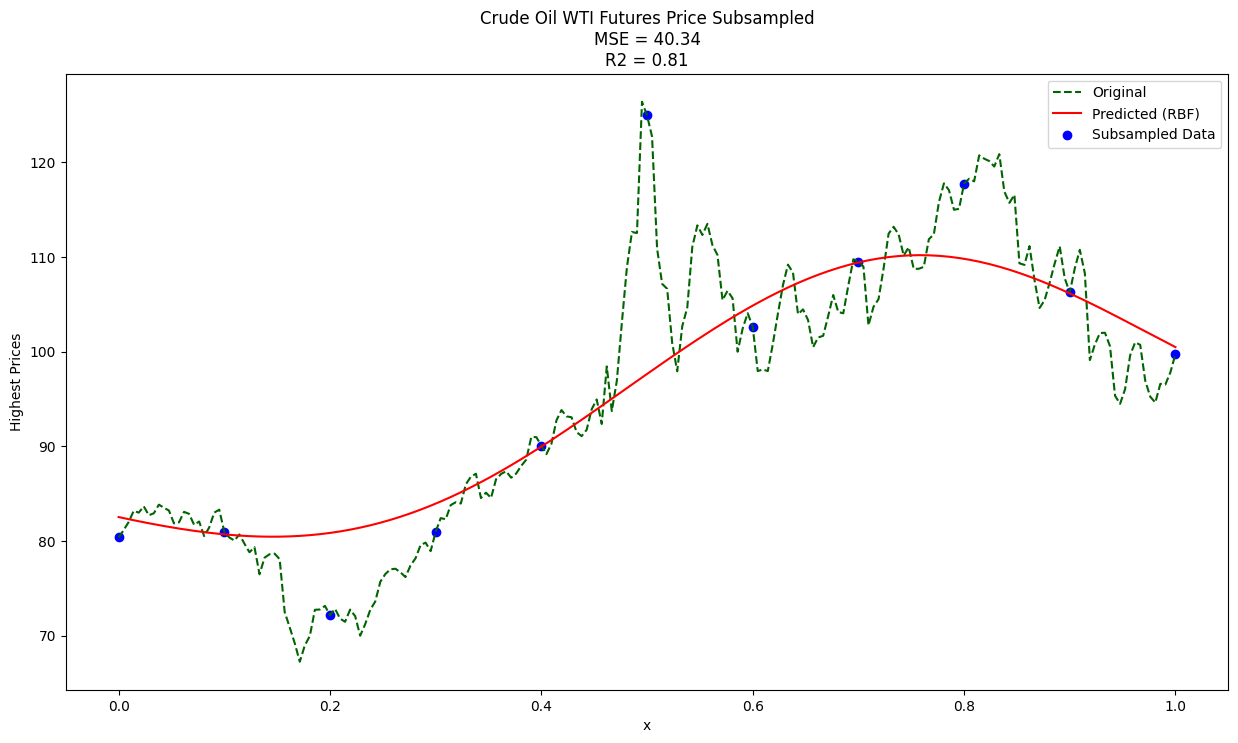

In [43]:
plt.figure(figsize=(15, 8))
plt.plot(X[:,0], y, label='Original', color='darkgreen', linestyle='--')
plt.plot(X[:,0], y_pred_rbf, label='Predicted (RBF)', color='red')
plt.scatter(data_series[:,0], data_series[:, 1], color='blue', label='Subsampled Data', marker='o')

plt.xlabel('x')
plt.ylabel('Highest Prices')
plt.title('Crude Oil WTI Futures Price Subsampled\n'
          f'MSE = {mean_squared_error(y, y_pred_rbf):.2f}\n'
          f'R2 = {r2_score(y, y_pred_rbf):.2f}')
plt.legend()
plt.show()

## Parameter Loss Landscape Exploration

In [146]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [147]:
matrices = np.array(params_list)

In [148]:
matrices.shape
# (num_trials, num_basis * num_intervals)

(700, 110)

In [165]:
pca = PCA(n_components=2, random_state=42)
embedded = pca.fit_transform(matrices)
embedded.shape

(700, 2)

In [166]:
# tsne = TSNE(n_components=2, random_state=42, perplexity=90)
# embedded = tsne.fit_transform(embedded_pca)

In [167]:
embedded.shape

(700, 2)

In [199]:
pca.explained_variance_

array([1.47836096, 0.52133691])

In [198]:
pca.components_.shape

(2, 110)

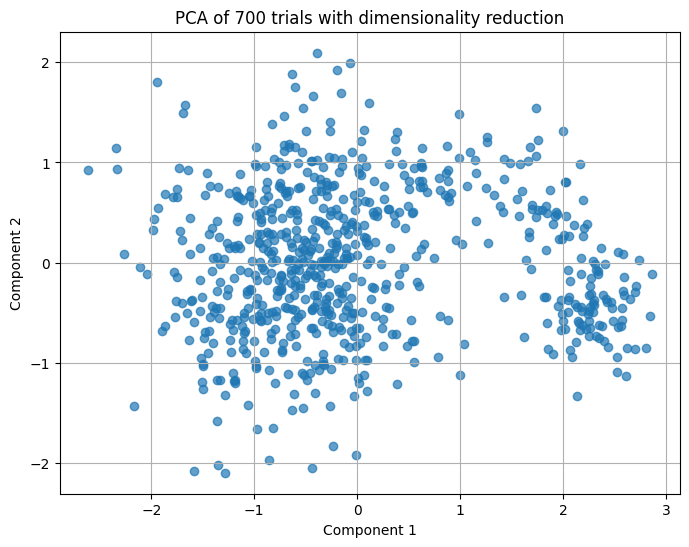

In [178]:
plt.figure(figsize=(8, 6))
plt.scatter(embedded[:, 0], embedded[:, 1], alpha=0.7)
plt.title(f'PCA of {matrices.shape[0]} trials with dimensionality reduction')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.show()

In [179]:
param_x = embedded[:, 0]
param_y = embedded[:, 1]
param_z = np.array(loss_list)

In [180]:
min_x, max_x = param_x.min(), param_x.max()
min_y, max_y = param_y.min(), param_y.max()

In [181]:
plot_x_i = np.linspace(min_x, max_x, 100)
plot_y_i = np.linspace(min_y, max_y, 100)
plot_x, plot_y = np.meshgrid(plot_x_i, plot_y_i)

In [182]:
from scipy.interpolate import griddata
plot_zi = griddata((param_x, param_y), param_z, (plot_x_i[None, :], plot_y_i[:, None]), method='linear')

In [183]:
# import matplotlib.tri as tri

# triang = tri.Triangulation(param_x, param_y)
# interpolator = tri.LinearTriInterpolator(triang, param_z)
# plot_zi = interpolator(plot_x, plot_y)

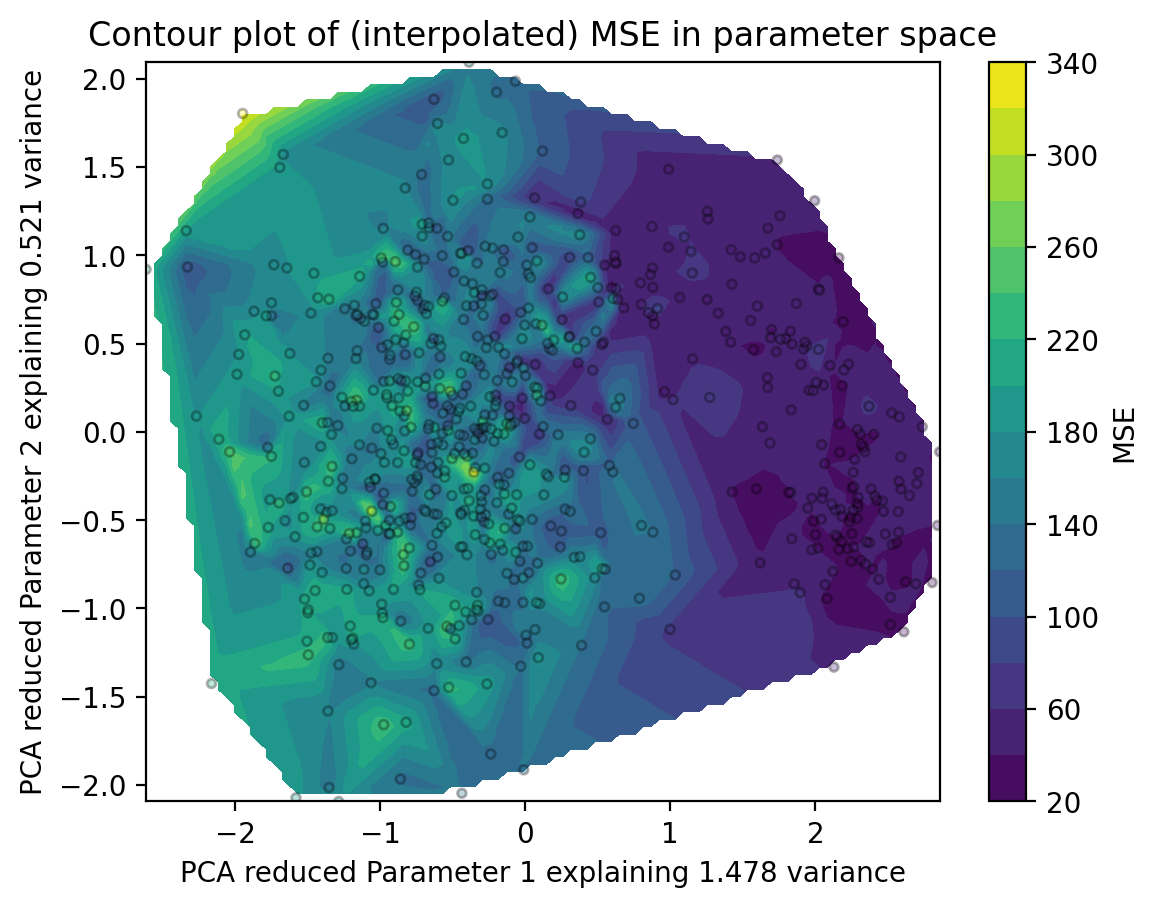

In [201]:
plt.figure(dpi=200)
plt.contourf(plot_x, plot_y, plot_zi, levels=15, cmap='viridis')
plt.colorbar(label='MSE')
plt.scatter(param_x, param_y, c=param_z, edgecolor='k', marker='o', alpha=0.3, s=10)

plt.title('Contour plot of (interpolated) MSE in parameter space')
plt.xlabel(f'PCA reduced Parameter 1 explaining {pca.explained_variance_[0]:.3f} variance')
plt.ylabel(f'PCA reduced Parameter 2 explaining {pca.explained_variance_[1]:.3f} variance')
plt.grid(False)
plt.show()